In [1]:
import copy
import configparser

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.colors as mp_colors
import matplotlib.pyplot as plt

C:\Users\Local Admin\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
def three_polar_plots(lfes_joined_fp, ephemeris_fp):
    join_unet = pd.read_csv(lfes_joined_fp, index_col = 0) 
#    join_unet = pd.read_csv(input_data_fp + "/LFEs_joined_ephemeris.csv", index_col = 0) 
    traj_df = pd.read_csv(ephemeris_fp)

    # pivot_table creation to count the amount of occurrences 
    join_unet['vals1'] = np.ones(np.shape(join_unet)[0])
    join_unet['lst1'] = np.ones(np.shape(join_unet)[0])
    join_unet['ranges1'] = np.ones(np.shape(join_unet)[0])

    # Set x, y conditions
    lst_times = np.arange(0, 25, 1)
    ranges = np.arange(0, 110, 10)

    # Restrict Range to [0,100]
#    join_unet_restrict = join_unet.iloc[np.where(join_unet['Range (RS)'] <= 100)[0]].reset_index()
    join_unet_restrict = join_unet.iloc[np.where(join_unet['R_ksm'] <= 100)[0]].reset_index()


    # Bin appropriately to conditions
    for i in range(np.shape(join_unet_restrict)[0]):
       # join_unet_restrict['lst1'].iloc[i] = lst_times[np.where(join_unet_restrict['LocalTime (hr)'].iloc[i] - lst_times >= 0)[0][-1]]
        join_unet_restrict['lst1'].iloc[i] = lst_times[np.where(join_unet_restrict['subLST'].iloc[i] - lst_times >= 0)[0][-1]]
       # join_unet_restrict['ranges1'].iloc[i] = ranges[np.where(join_unet_restrict['Range (RS)'].iloc[i] - ranges >= 0)[0][-1]]
        join_unet_restrict['ranges1'].iloc[i] = ranges[np.where(join_unet_restrict['R_ksm'].iloc[i] - ranges >= 0)[0][-1]]


 #   Z1 = pd.pivot_table(join_unet_restrict, index = 'ranges1', columns = 'lst1', values = 'vals1', aggfunc = sum, fill_value = 0)
    LST, R = np.meshgrid(lst_times, ranges)

    # Use Range for x_label
    max_range = 100
    max_lst = 24

    range_bin_size = 10
    lst_bin_size = 1

    range_bins = int(max_range / range_bin_size)
    lst_bins = int(max_lst / lst_bin_size)

    # Spacecraft ephemeris provided by SPICE files
    spacecraft_times = traj_df["start"]
    spacecraft_ranges = traj_df["R_ksm"]
    spacecraft_LST = traj_df["subLST"]

    # Spacecraft positions at LFE occurences
    lfe_starts = join_unet["start"]
    #lfe_ranges = join_unet["Range (RS)"]
    lfe_ranges = join_unet["R_ksm"]
   # lfe_LST = join_unet["LocalTime (hr)"]
    lfe_LST = join_unet["subLST"]

    mesh_inner_edges = {
        "r": (np.arange(0, range_bins + 1) * max_range) / range_bins, # ranging from 1 to max_range - bin size
        "lst": (np.arange(0, lst_bins + 1) * max_lst) / lst_bins
    }
    mesh_outer_edges = {
        "r": (np.arange(1, range_bins + 1) * max_range) / range_bins, # ranging from 2 + bin size TO max_range
        "lst": (np.arange(1, lst_bins + 1) * max_lst) / lst_bins
    }

    # Bin Initialization
    timeSpentInBin = np.zeros((range_bins + 1, lst_bins + 1))
    lfe_detections_in_bin = np.zeros((range_bins + 1, lst_bins + 1))
    lfe_duration_in_bin = np.zeros((range_bins + 1, lst_bins + 1))
    norm_detections_in_bin= np.zeros((range_bins + 1, lst_bins + 1))
    norm_duration_in_bin= np.zeros((range_bins + 1, lst_bins + 1))
    norm_det_dur_in_bin = np.zeros((range_bins + 1, lst_bins + 1))

    # R & LST Pairing
    for mesh_r in range(len(mesh_outer_edges["r"])):
        for mesh_lst in range(len(mesh_outer_edges["lst"])):
            # Determines at which time indices (in spacecraft's COMPLETE ephemeris data) it will be within the current bin
            time_indices_in_region = np.where((spacecraft_LST < mesh_outer_edges["lst"][mesh_lst]) & (spacecraft_LST >= mesh_inner_edges["lst"][mesh_lst]) &\
                                            (spacecraft_ranges < mesh_outer_edges["r"][mesh_r]) & (spacecraft_ranges >= mesh_inner_edges["r"][mesh_r]))
                # How much total time during the entire mission Cassini spent at that specific range (i.e. 10->20 Rs)
            
            # Determines at which time indices (in joined LFE list) it will be in the current bin
            lfe_indices_in_region = np.where((lfe_LST <= mesh_outer_edges["lst"][mesh_lst]) & (lfe_LST > mesh_inner_edges["lst"][mesh_lst]) &\
                                            (lfe_ranges <= mesh_outer_edges["r"][mesh_r]) & (lfe_ranges > mesh_inner_edges["r"][mesh_r]))

            # Get the time spent in the current bin TRANSFORMED into minutes
            timeInRegion = len(time_indices_in_region[0])
            if timeInRegion == 0: timeInRegion = np.nan
            timeSpentInBin[mesh_r][mesh_lst] = timeInRegion

            lfe_detections_in_region = len(lfe_indices_in_region[0])
            if lfe_detections_in_region == 0: lfe_detections_in_region = 0
            lfe_detections_in_bin[mesh_r][mesh_lst] = lfe_detections_in_region

            duration_sums = np.sum(join_unet.iloc[lfe_indices_in_region[0]]['duration'])
            if len(lfe_indices_in_region[0]) == 0: duration_sums = 0
            lfe_duration_in_bin[mesh_r][mesh_lst] = duration_sums / (60*60) # In Hours

            norm_detections_in_bin[mesh_r][mesh_lst] = (lfe_detections_in_region / (timeInRegion / 60)) * 100 # lfe / hour count
            
            norm_duration_in_bin[mesh_r][mesh_lst] = ((duration_sums / (60*60)) / (timeInRegion / 60)) * 100 # Total LFE Duration / Observing TIme in Bin (Hrs)

            norm_det_dur_in_bin[mesh_r][mesh_lst] = norm_duration_in_bin[mesh_r][mesh_lst] / norm_detections_in_bin[mesh_r][mesh_lst] # Average lfe duration in bin

    # Shading flat requires removing last point
    timeSpentInBin = timeSpentInBin[:-1,:-1]
    lfe_detections_in_bin = lfe_detections_in_bin[:-1,:-1]
    norm_detections_in_bin = norm_detections_in_bin[:-1,:-1]
    lfe_duration_in_bin = lfe_duration_in_bin[:-1, :-1]
    norm_duration_in_bin=norm_duration_in_bin[:-1, :-1]
    norm_det_dur_in_bin = norm_det_dur_in_bin[:-1, :-1]

    total_cassini_time = np.shape(traj_df)[0]
    timeSpentInBin_per = (timeSpentInBin / total_cassini_time)*100

    # Figure set up
   # fig = plt.figure(figsize = (15, 10))
    fig = plt.figure(figsize = (9, 6))
    
    ax_time = fig.add_subplot(1, 3, 1, projection = "polar") # 1st subplot in layout with 1 row and 3 columns of subplots
    ax_lfes = fig.add_subplot(1, 3, 2, projection = "polar")
   # ax_lfdur = fig.add_subplot(2, 3, 3, projection = "polar")
   # ax_norm = fig.add_subplot(2, 3, 4, projection = "polar")
    ax_dur = fig.add_subplot(1, 3, 3, projection = "polar")
   # ax_dur_det = fig.add_subplot(2, 3, 6, projection = "polar")

    csize=10

    # Label the Ticks
    xtickpos = []
    xticklab = []
    for i in range(0, 24):
        xtickpos.append((i) * ((2*np.pi)/24.0))
        xticklab.append('%02d' % (i))

    # Convert LST into angle (considering 00 at 0deg)
    lst_times = (np.arange(0, 25)) * ((2*np.pi) / 24)
    ranges = np.arange(0, 110, 10)

    # Uniform Meshgrid 
    LST, R = np.meshgrid(lst_times, ranges)
    cmap = copy.copy(matplotlib.cm.get_cmap("inferno"))
    cmap.set_under(color='grey')  

    # % observing time plot
    ax_time.set_title("Residence Time (%) \n 0 ($R_S$) < Range < 100 ($R_S$)", fontsize = csize * (17/15))
    pcm_time = ax_time.pcolor(LST, R, timeSpentInBin_per, edgecolor = 'white', linewidth = 0.2, cmap = cmap)
    cbar_time = fig.colorbar(pcm_time, ax = ax_time, fraction = 0.046, pad = 0.1, orientation = 'horizontal')
    cbar_time.ax.tick_params(labelsize = csize)
    cbar_time.set_label(size = csize, label = "% Observing Time")
    #pcm_time.set_clim(np.min(timeSpentInBin_per, where=~np.isnan(timeSpentInBin_per), initial = 1), np.max(timeSpentInBin_per, where=~np.isnan(timeSpentInBin_per), initial = 1))
    ax_time.set_facecolor("grey")

    ax_time.spines['polar'].set_visible(False)
    ax_time.set_xticks(xtickpos)
    ax_time.set_xticklabels(xticklab)
    ax_time.set_yticks([10,20,30,40,50,60,70,80,90])
    ax_time.set_yticklabels([10, 20, 30, 40 , 50, 60, 70, 80, 90], color = 'white', fontsize = csize * (17/15))
    ax_time.set_theta_zero_location('S') # Make sure 00 is at NORTH Position
    ax_time.set_theta_direction("counterclockwise")
    ax_time.tick_params(labelsize=csize)
    ax_time.text(-150, 165,'(a)', va = 'bottom', ha = 'right', fontsize = csize * (17/15))
    lab_pos = ax_time.get_rlabel_position()
    ax_time.text(np.radians(lab_pos - 15), ax_time.get_rmax() * 0.75, '$R_S$', ha = 'center', va = 'center', fontsize = csize, color = 'white')


    # LFE count plot
    norm=mp_colors.LogNorm(vmin=1, vmax=190)
   # pcolormesh(LST, R, lfe_detections_in_bin, norm=norm, zorder=1)

    ax_lfes.set_title("LFE Detections \n 0 ($R_S$) < Range < 100 ($R_S$)", fontsize = csize * (17/15))
    pcm_lfe = ax_lfes.pcolor(LST, R, lfe_detections_in_bin, edgecolor = 'white', linewidth = 0.2, cmap = cmap, norm=norm, zorder=1)
    cbar_lfe = fig.colorbar(pcm_lfe, ax = ax_lfes, fraction = 0.046, pad = 0.1, orientation = 'horizontal')
    cbar_lfe.ax.tick_params(labelsize = csize)
    cbar_lfe.set_label(size = csize, label = "LFE Detections")
    #cbar_lfe.set_ticks([1, 20, 40, 60, 80, 100, 120, 140, 160])
    ax_lfes.set_facecolor("grey")

    ax_lfes.spines['polar'].set_visible(False)
    ax_lfes.set_yticks([10,20,30,40,50,60,70,80,90])
    ax_lfes.set_yticklabels([10, 20, 30, 40 , 50, 60, 70, 80, 90], color = 'white', fontsize = csize * (17/15))
    ax_lfes.set_xticks(xtickpos)
    ax_lfes.set_xticklabels(xticklab, color = 'black')
    ax_lfes.set_theta_zero_location('S') # Make sure 00 is at NORTH Position
    ax_lfes.set_theta_direction("counterclockwise")
    ax_lfes.tick_params(labelsize=csize)
    ax_lfes.text(-150, 165,'(b)', va = 'bottom', ha = 'right', fontsize = csize * (17/15))
    lab_pos = ax_lfes.get_rlabel_position()
    ax_lfes.text(np.radians(lab_pos - 15), ax_lfes.get_rmax() * 0.75, '$R_S$', ha = 'center', va = 'center', fontsize = csize, color = 'white')

    # Duration Normalization plot
    ax_dur.set_title("Total LFE Duration normalized by Observing Time \n 0 ($R_S$) < Range < 100 ($R_S$)", fontsize = csize * (17/15))
    pcm_dur = ax_dur.pcolor(LST, R, norm_duration_in_bin, edgecolor = 'white', linewidth = 0.2, cmap = cmap)
    cbar_dur = fig.colorbar(pcm_dur, ax = ax_dur, fraction = 0.046, pad = 0.1, orientation = 'horizontal', )
    cbar_dur.ax.tick_params(labelsize = csize)
    cbar_dur.set_label(size=csize,label="Occurrence (%)")
#    cbar_dur.set_label(size = csize* (20/15), label = r' $\\frac{Summed \; LFE\; Duration}{Observing\; Time\; per\; Bin\;}$ $\times$ 100' )
 #160126: Need to correct formatting to stop this label being in italics
    #   cbar_dur.set_label(size = csize* (20/15), label = r' $\text{\\frac{Summed \; LFE\; Duration{Observing\; Time\; per\; Bin\;}}$ $\times$ 100' )
    ax_dur.set_facecolor("grey")

    ax_dur.spines['polar'].set_visible(False)
    ax_dur.set_yticks([10,20,30,40,50,60,70,80,90])
    ax_dur.set_yticklabels([10, 20, 30, 40 , 50, 60, 70, 80, 90], color = 'white', fontsize = csize * (17/15))
    ax_dur.set_xticks(xtickpos)
    ax_dur.set_xticklabels(xticklab)
    ax_dur.set_theta_zero_location('S') # Make sure 00 is at NORTH Position
    ax_dur.set_theta_direction("counterclockwise")
    ax_dur.tick_params(labelsize=csize)
    ax_dur.text(-150, 165,'(e)', va = 'bottom', ha = 'right', fontsize = csize * (17/15))
    lab_pos = ax_dur.get_rlabel_position()
    ax_dur.text(np.radians(lab_pos - 15), ax_dur.get_rmax() * 0.75, '$R_S$', ha = 'center', va = 'center', fontsize = csize, color = 'white')


    t = ax_time.text(0.005, 1.05, "A", transform=ax_time.transAxes,fontsize=15, va='bottom', ha='left')
    t.set_bbox(dict(facecolor='white', alpha=0.75, edgecolor='grey'))
        
    t = ax_lfes.text(0.005, 1.05, "B", transform=ax_lfes.transAxes,fontsize=15, va='bottom', ha='left')
    t.set_bbox(dict(facecolor='white', alpha=0.75, edgecolor='grey'))
        
    t = ax_dur.text(0.005, 1.05, "C", transform=ax_dur.transAxes,fontsize=15, va='bottom', ha='left')
    t.set_bbox(dict(facecolor='white', alpha=0.75, edgecolor='grey'))
        
        
    fig.tight_layout()
    #plt.savefig("/Users/hannamag/Desktop/LFE_statistics_original/Sample_Visualizations/Polar_Plot.jpeg", dpi = 300)
    plt.savefig("Residence_Visibility_polarplots.pdf",format="pdf")
    plt.show()

In [3]:
# Filepaths
lfes_joined_fp = '../data/calculated/LFEs_joined.csv'
ephemeris_fp = '../data/calculated/20040101000000_20170915115700_ephemeris.csv'

C:\Users\Local Admin\AppData\Local\Temp\ipykernel_15472\233321867.py:23: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  join_unet_restrict['lst1'].iloc[i] = lst_times[np.where(join_unet_restrict['subLST'].iloc[i] - lst_times >= 0)[0][-1]]
C:\

C:\Users\Local Admin\AppData\Local\Temp\ipykernel_15472\233321867.py:23: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  join_unet_restrict['lst1'].iloc[i] = lst_times[np.where(join_unet_restrict['subLST'].iloc[i] - lst_times >= 0)[0][-1]]
C:\

C:\Users\Local Admin\AppData\Local\Temp\ipykernel_15472\233321867.py:25: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  join_unet_restrict['ranges1'].iloc[i] = ranges[np.where(join_unet_restrict['R_ksm'].iloc[i] - ranges >= 0)[0][-1]]
C:\User

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)

C:\Users\Local Admin\AppData\Local\Temp\ipykernel_15472\233321867.py:25: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a

C:\Users\Local Admin\AppData\Local\Temp\ipykernel_15472\233321867.py:99: RuntimeWarning: invalid value encountered in scalar divide
  norm_det_dur_in_bin[mesh_r][mesh_lst] = norm_duration_in_bin[mesh_r][mesh_lst] / norm_detections_in_bin[mesh_r][mesh_lst] # Average lfe duration in bin
C:\Users\Local Admin\AppData\Local\Temp\ipykernel_15472\233321867.py:138: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(matplotlib.cm.get_cmap("inferno"))


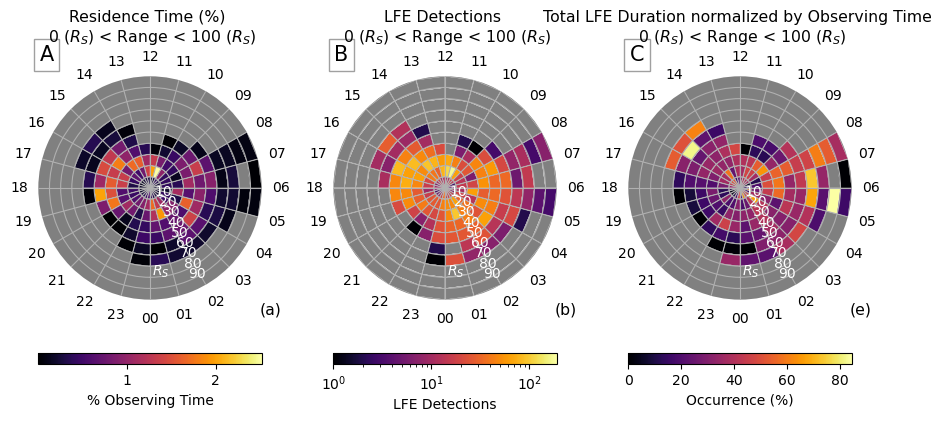

In [4]:
three_polar_plots(lfes_joined_fp, ephemeris_fp)